In [41]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,12_ema,27_ema,MACD,Signal,MACD_hist,RSI,MACD_Strategy,RSI_Strategy,Full_Strategy,Strategy,Asset_Returns,Strategy_Returns
13,121.461143,132.041763,117.283712,121.087419,3743115,144.398741,150.359444,-5.960704,-2.952258,-3.008445,27.835150,NaN,NaN,NaN,0,NaN,NaN
14,127.307823,129.973744,123.744970,123.744970,1696795,141.535719,147.905484,-6.369765,-3.660685,-2.709080,32.550533,1.0,1.0,2.0,1,0.048136,0.048136
15,132.556656,134.342233,125.406021,127.565335,3101715,140.051858,146.326820,-6.274961,-4.198684,-2.076278,33.482837,1.0,0.0,1.0,0,0.091350,0.048136
16,134.217651,138.195757,131.717841,132.880540,3009285,139.098588,145.119307,-6.020719,-4.571485,-1.449233,23.977399,1.0,0.0,1.0,0,0.105025,0.048136
17,130.845840,135.330555,128.769582,134.541579,1888275,137.762897,143.735131,-5.972235,-4.856775,-1.115460,20.039585,1.0,1.0,2.0,1,0.077265,0.021805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6295,176.160004,187.250000,172.169998,187.000000,6327143,178.610521,164.194879,14.415642,15.486266,-1.070624,55.536629,-1.0,0.0,-1.0,0,0.450340,-0.997972
6296,193.089996,193.770004,175.059998,176.160004,13780639,180.838133,166.258816,14.579316,15.304876,-0.725560,61.597717,1.0,0.0,1.0,0,0.589726,-0.997972
6297,184.860001,195.910004,183.520004,189.990005,7376659,181.456882,167.587472,13.869409,15.017783,-1.148373,58.326508,1.0,0.0,1.0,0,0.521968,-0.997972
6298,188.559998,193.000000,182.330002,190.000000,6524220,182.549669,169.085510,13.464159,14.707058,-1.242899,62.205055,1.0,0.0,1.0,0,0.552431,-0.997972


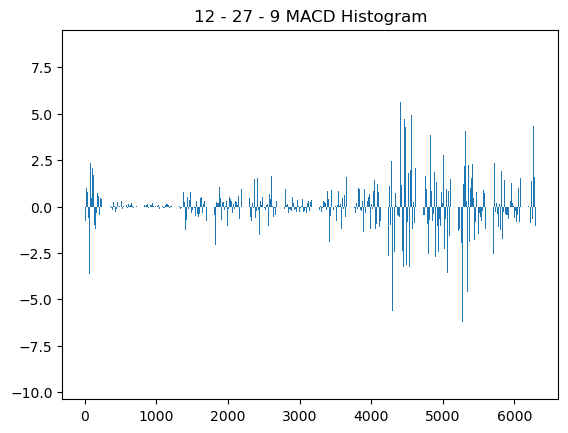

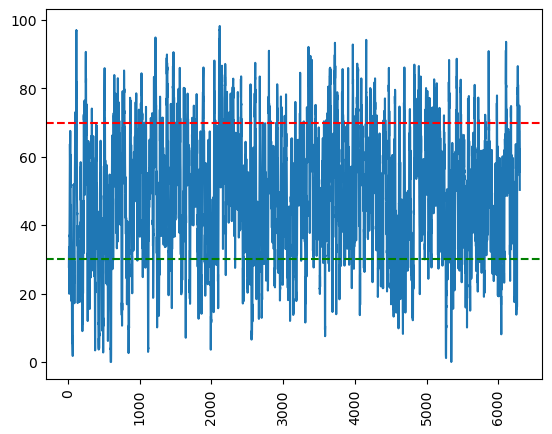

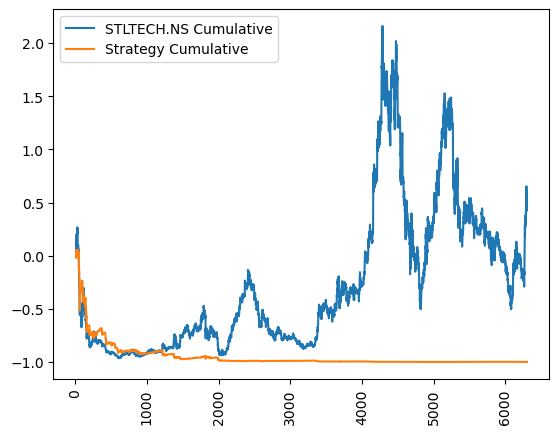

In [59]:
TICKER = 'STLTECH.NS'
RSI_LENGTH = 14
OVERBOUGHT = 70
OVERSOLD = 30 
PERIOD = '730d'
INTERVAL = '1d'
LOOKBACK = 10000
MACD_FAST = 12
MACD_SLOW = 27
MACD_SPAN = 9

def get_data(ticker=TICKER,lookback=LOOKBACK,interval=INTERVAL):


    df = yf.download(ticker,start='2000-01-01',interval=interval)
    df.columns = df.columns.get_level_values(0)

    #reset the index, so the weekends does not come in account
    df=df.reset_index(drop=True)

    return df.iloc[-lookback:, :]

def add_MACD(df, fast=MACD_FAST,slow=MACD_SLOW, span=MACD_SPAN):

    df[f'{fast}_ema'] = df['Close'].ewm(span=fast).mean()
    df[f'{slow}_ema'] = df['Close'].ewm(span=slow).mean()

    #macd line is the difference between the fast and slow
    df[f'MACD'] = df[f'{fast}_ema'] - df[f'{slow}_ema']

    #macd signal is a 9-period moving average of this line
    df['Signal'] = df['MACD'].ewm(span=span).mean()

    #macd histogram is almost always what is used in TA
    df['MACD_hist'] = df['MACD'] - df['Signal']

    #plot the histogram
    plt.bar(x=range(len(df)), height=df['MACD_hist'])
    plt.title(f'{MACD_FAST} - {MACD_SLOW} - {MACD_SPAN} MACD Histogram')

    return df

def add_MACD_strategy(df):

    df['MACD_Strategy'] = 0
    df['MACD_Strategy'] = np.where(df['MACD_hist'] < 0,1,-1)
    df['MACD_Strategy'] = df['MACD_Strategy'].shift(1)

    return df

def add_RSI(df, length=RSI_LENGTH):
    
    price_change = df['Close'].diff() #calculating delta

    #separate gains and losses
    gain = price_change.where(price_change > 0, 0 )
    loss = -price_change.where(price_change < 0, 0 )

    #average gains and losses
    avg_gain = gain.rolling(window=length).mean()
    avg_loss = loss.rolling(window=length).mean()

    #calculate rsi
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    df['RSI'] = rsi


    #plotting the graph
    plt.figure()
    plt.plot(df['RSI'])
    plt.axhline(OVERBOUGHT, color='red', linestyle='--')
    plt.axhline(OVERSOLD, color='green', linestyle='--')
    plt.xticks(rotation='vertical')

    return df.dropna()

def add_RSI_strategy(df, overbought=OVERBOUGHT, oversold=OVERSOLD):
    
    df['RSI_Strategy'] = 0
    df['RSI_Strategy'] = np.where(df['RSI'] > overbought, -1,
                     np.where(df['RSI'] < oversold, 1, 0))
    df['RSI_Strategy'] = df['RSI_Strategy'].shift(1) #shifting back to see the signal

    return df


def add_full_strategy(df):
    
    df['Full_Strategy'] = df['MACD_Strategy'] + df['RSI_Strategy']

    df['Strategy'] = np.where(df['Full_Strategy'] ==2, 1,
                     np.where(df['Full_Strategy'] == -2,-1,0 ))

    return df

def test_strategy(df):
    df['Asset_Returns'] = (1+df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = ( 1 + df['Close'].pct_change() * df['Strategy']).cumprod() - 1

    #plotting the strategy
    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', 'Strategy Cumulative'])
    plt.xticks(rotation='vertical')

    return df


def main():
    df = get_data()
    df = add_MACD(df)
    df = add_RSI(df)

    df = add_MACD_strategy(df)
    df = add_RSI_strategy(df)

    df = add_full_strategy(df)

    df = test_strategy(df)

    return df

df = main()
df

In [60]:
df['Full_Strategy'].value_counts()

Full_Strategy
 1.0    2307
-1.0    2224
 2.0     849
-2.0     831
 0.0      75
Name: count, dtype: int64